# Movies (`getmovie` / `savemovie`)

[`getmovie`](@ref) projects a quantity for **every output** of a simulation and collects the
maps into the frames of a movie; [`savemovie`](@ref) writes them to an animated GIF. It
builds on the same machinery as [`timeseries`](@ref) (one snapshot resident at a time,
RAM-safe) and the [`projection`](@ref) engine. Down a box axis the view is fixed by construction; off
axis it is not, and `fov` is what makes it so (see below).

![A 3-D Sedov blast over its first 36 outputs, each frame tagged with its output number (tags=:output): the column-density frames produced by getmovie, encoded to a GIF by savemovie.](assets/movie/sedov_density.gif)

This notebook runs on the `timeseries_sedov3d` test run (a 3-D Sedov blast, 13 outputs). All
file outputs are written to a temporary directory.

!!! note "What you are looking at"
    A point explosion set off in one corner cell of a small periodic box. The shell
    expands, wraps through the faces and arrives from every side, so it appears as four
    quarter arcs closing in. The movie stops before the wrapped copies collide.


In [1]:
# Example-data root. Point this at your own simulation folder, or set the
# MERA_EXAMPLES environment variable; every path below is built from it.
MERA_EXAMPLES = get(ENV, "MERA_EXAMPLES", "/Volumes/FASTStorage/Simulations/Mera-Tests");

using Mera
run  = joinpath(MERA_EXAMPLES, "RAMSES/timeseries_sedov3d")
tmp  = mktempdir()
println("temp output dir : ", tmp)

# one column-density frame per output (numeric maps, no files written).
# `outputs` picks a subset; leave it out and every output in the run is used.
m = getmovie(run, :sd; outputs=1:36, res=256)
println("frames          : ", length(m.frames))
println("frame size      : ", size(m.frames[1]))
println("output numbers  : ", m.outputs)


*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0 | Julia 1.12.7 | 4 threads

temp output dir : 

/var/folders/k5/gw4hqgwj5_qf8sljz0091x1m0000gp/T/jl_IvvUEF
getmovie: 36 frame(s) of :sd from "/Volumes/FASTStorage/Simulations/Mera-Tests/RAMSES/timeseries_sedov3d"


  [1/36] output 00001


  [2/36] output 00002


...

  [34/36] output 00034


  [35/36] output 00035


  [36/36] output 00036


frames          : 36
frame size      : (256, 256)
output numbers  : 

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


## How it works (no scratch images)

The pipeline is **simulation outputs → in-memory numeric maps → one GIF**, it does *not*
write a folder of PNGs and stitch them, and it does *not* read existing image files:

1. `getmovie` loops the outputs, loading **one snapshot at a time** (released before the
   next, like `timeseries`), and `projection`s each into an in-memory 2-D numeric array
   (`Matrix{Float64}`). These accumulate in `m.frames`, no files are written.
2. `savemovie` takes those numeric frames, applies the log/colormap/normalisation, and
   writes a **single** animated GIF in one `FileIO.save` call (using the bundled
   FileIO/Images, no extra package). No per-frame temp files.

The frames stay numeric, so you can post-process them or render them yourself. If you *do*
want the individual images on disk, ask for them, `savemovie(...; save_frames="dir/")` writes
each rendered frame as a PNG (see [Scratch frames](#Scratch-frames-—-keep-the-PNGs)), and
[`moviefromframes`](@ref) goes the other way, building a movie from images already on disk.

## Orientation: off-axis movies

`getmovie` is axis-aligned by default (`direction=:z`), and every off-axis control that
`projection` offers works here too:

```julia
# a line of sight from the auto-frame (face-on / edge-on)
ref = gethydro(getinfo(1, "/data/sim"))
fr  = face_on(ref)
m   = getmovie("/data/sim", :sd; los=fr.los, up=fr.up, center=fr.center, range_unit=fr.center_unit)

# by viewing angles
m = getmovie("/data/sim", :sd; inclination=60, azimuth=30)      # degrees by default
```

!!! warning "An off-axis movie is not steady unless you say so"
    Down a box axis the window is fixed by construction. Off axis it is not: the projection
    fits its window to the rotated data, and that footprint changes from snapshot to snapshot.
    The object then appears to zoom, only the first frame's extent is recorded, and if two
    snapshots produce different pixel dimensions the encode stops outright.

    Pass `fov`/`fov_unit` (with `aperture=:circle|:square`) to select a fixed sphere about
    `center`. Every frame then shares one window, which is what [`rotation_sequence`](@ref)
    has always done for its angle sweeps.

```julia
m = getmovie("/data/sim", :sd; inclination=60, axis=:angmom,
             fov=15, fov_unit=:kpc, aperture=:square, pxsize=[0.5, :kpc])
```

`axis=:angmom` deserves the same caution. It re-derives the orientation from each snapshot's
own angular momentum, so if the disc's spin drifts, the camera drifts with it and the series
tumbles. For a steady series, measure the orientation once and freeze it as `los=`.

`res`, `pxsize`, `lmax` and the `xrange`/`yrange`/`zrange` region keywords cut the cost and
memory of each frame. `outputs` selects which snapshots (`:all`, a range, or a vector), and
`mera_files=true` reads `output_*.jld2` mera files instead of RAMSES outputs, exactly as in
[`timeseries`](@ref).

## Moving the camera on purpose

The frames so far differ only in time. Two keywords add camera motion, and they make different
movies:

| between frames, what changes | keyword | frames |
|---|---|---|
| time only | neither | one per output |
| a full turn at **each** snapshot | `angles` | outputs x angles |
| time **and** angle together | `sweep` | one per output |

Neither interpolates. Every frame is a real projection from a real viewpoint, so nothing in the
result is invented.

`angle_var` chooses which angle they drive: `:azimuth` (default), `:inclination` or
`:position_angle`. Driving an angle you also set explicitly is an error rather than a silent
override.

In [2]:
# orbit, then step time: a turn at every snapshot
orbit = getmovie(run, :sd; angles=0:120:240, fov=0.3, fov_unit=:standard,
                 aperture=:square, inclination=50, res=64, verbose=false)
println("angles : ", length(orbit.frames), " frames from ",
        length(unique(orbit.outputs)), " outputs")

# orbit while time passes: one frame per snapshot, at a moving angle
turning = getmovie(run, :sd; sweep=(0, 180), fov=0.3, fov_unit=:standard,
                   aperture=:square, inclination=50, res=64, verbose=false)
println("sweep  : ", length(turning.frames), " frames, each a different time and angle")
println("every frame the same size: ",
        all(size(f) == size(orbit.frames[1]) for f in orbit.frames))

angles : 129 frames from 43 outputs


sweep  : 43 frames, each a different time and angle
every frame the same size: true


The same call works on particles. The weighting differs between the two paths (particles take a
bare `Symbol` where hydro takes a `[quantity, unit]` pair), which `getmovie` now handles for you.

The Sedov run above carries no particles, so this uses a different fixture: a small
gravity-plus-particle series.

In [3]:
prun = joinpath(MERA_EXAMPLES, "RAMSES-PUBLIC/sedov3d_grav_part")
pm   = getmovie(prun, :sd; datatype=:particles, res=64, verbose=false)
println("particle frames : ", length(pm.frames), "  size ", size(pm.frames[1]))
println("outputs         : ", pm.outputs)

particle frames : 7  size (64, 64)
outputs         : [1, 2, 3, 4, 5, 6, 7]


## Save to a GIF

`savemovie` takes the numeric frames, applies the log/colormap/normalisation, and writes a
single animated GIF. `tags=:output` burns the output number onto each frame.

In [4]:
gif = joinpath(tmp, "density.gif")
savemovie(m, gif; tags=:output)
println("wrote GIF       : ", gif, "  (", filesize(gif), " bytes)")

  frame 1: output 00001


  frame 2: output 00002
  frame 3: output 00003
  frame 4: output 00004
  frame 5: output 00005
  frame 6: output 00006
  frame 7: output 00007
  frame 8: output 00008
  frame 9: output 00009
  frame 10: output 00010
  frame 11: output 00011


  frame 12: output 00012
  frame 13: output 00013
  frame 14: output 00014
  frame 15: output 00015
  frame 16: output 00016
  frame 17: output 00017
  frame 18: output 00018
  frame 19: output 00019
  frame 20: 

output 00020
  frame 21: output 00021
  frame 22: output 00022
  frame 23: output 00023
  frame 24: output 00024
  frame 25: output 00025
  frame 26: output 00026
  frame 27: output 00027
  frame 28: output 00028
  frame 29: output 00029
  frame 30: output 00030
  frame 31: output 00031
  frame 32: output 00032
  frame 33: output 00033
  frame 34: output 00034
  frame 35: output 00035
  frame 36: output 00036
savemovie: wrote 36 frames → /var/folders/k5/gw4hqgwj5_qf8sljz0091x1m0000gp/T/jl_IvvUEF/density.gif


wrote GIF       : /var/folders/k5/gw4hqgwj5_qf8sljz0091x1m0000gp/T/jl_IvvUEF/density.gif  (466105 bytes)


## Saving: colormap, scaling, steady brightness

In [5]:
gif2 = joinpath(tmp, "density_gray.gif")
savemovie(m, gif2;
          colormap   = :gray,
          log        = true,
          colorrange = :global,
          clip       = (0.0, 0.999),
          tags       = :time,        # "t = … Myr" on each frame
          fps        = 8)
println("wrote          : ", gif2, "  (", filesize(gif2), " bytes)")

  frame 1: t=0.0 Myr


  frame 2: t=6.025e-17 Myr
  frame 3: t=1.212e-16 Myr
  frame 4: t=1.845e-16 Myr
  frame 5: t=2.415e-16 Myr
  frame 6: t=3.03e-16 Myr
  frame 7: t=3.633e-16 Myr
  frame 8: t=4.268e-16 Myr
  frame 9: t=4.82e-16 Myr
  frame 10: t=5.448e-16 Myr
  frame 11: t=6.039e-16 Myr
  frame 12: t=6.646e-16 Myr
  frame 13: t=7.27e-16 Myr
  frame 14: t=7.845e-16 Myr
  frame 15: t=8.432e-16 Myr
  frame 16: t=9.031e-16 Myr
  frame 17: t=9.642e-16 Myr
  frame 18: t=1.026e-15 Myr
  frame 19: t=1.09e-15 Myr
  frame 20: t=1.147e-15 Myr
  frame 21: t=1.204e-15 Myr
  frame 22: t=1.27e-15 Myr
  frame 23: t=1.33e-15 Myr
  frame 24: 

t=1.39e-15 Myr
  frame 25: t=1.451e-15 Myr
  frame 26: t=1.513e-15 Myr
  frame 27: t=1.567e-15 Myr
  frame 28: t=1.63e-15 Myr
  frame 29: t=1.686e-15 Myr
  frame 30: t=1.75e-15 Myr
  frame 31: t=1.807e-15 Myr
  frame 32: t=1.872e-15 Myr
  frame 33: t=1.93e-15 Myr
  frame 34: t=1.988e-15 Myr
  frame 35: t=2.055e-15 Myr
  frame 36: t=2.115e-15 Myr
savemovie: wrote 36 frames → /var/folders/k5/gw4hqgwj5_qf8sljz0091x1m0000gp/T/jl_IvvUEF/density_gray.gif


wrote          : /var/folders/k5/gw4hqgwj5_qf8sljz0091x1m0000gp/T/jl_IvvUEF/density_gray.gif  (437733 bytes)


- **`colorrange=:global`** (default) computes a single range over *all* frames, so the movie
  doesn't flicker as the peak grows. Use `:perframe` to stretch each frame independently, or
  pass an explicit `(lo, hi)` (in log space when `log=true`).
- **`colormap`** is `:fire` or `:gray` out of the box (no colour-package dependency), or any
  function mapping `t∈[0,1]` to an `(r, g, b)` tuple, e.g. plug in a `ColorSchemes`/Makie
  colormap if you have one loaded.


## Tags: a timestamp or label on each frame

Pass `tags` to label every frame. The labels are **printed** as the movie is written and,
with `annotate=true` (the default), **burned onto the frames** with a small built-in bitmap
font (top-left, no font dependency).

`tags` accepts:

- `:time` → the frame's physical time and unit; `:output` → its output number;
- a **vector of strings** (one per frame), any custom caption you like;
- a **function** `k -> String` (frame index → label), e.g. `k -> "z = $(redshifts[k])"`;
- a **tuple** of any of the above to stack **multiple lines**, e.g. `tags=(:output, :time)`.

Control how the labels look, all optional, with sensible defaults:

| keyword | default | options |
|---------|---------|---------|
| `tag_scale` | `:auto` | `:auto` (scales with the frame) or an integer font size |
| `tag_position` | `:topleft` | `:topleft`, `:topright`, `:bottomleft`, `:bottomright`, or `(row, col)` |
| `tag_color` | `:white` | `:white`, `:yellow`, `:red`, `:cyan`, `:green`, `:black`, an `RGB`, or `(r,g,b)` |

In [6]:
gif3 = joinpath(tmp, "density_tagged.gif")
captions = ["frame $(k)/$(length(m.frames))" for k in 1:length(m.frames)]
savemovie(m, gif3;
          tags = (:output, :time),          # two stacked lines
          tag_position = :bottomright,
          tag_color    = :yellow)
println("two-line tags  : ", basename(gif3))

gif4 = joinpath(tmp, "density_custom.gif")
savemovie(m, gif4; tags = captions)         # custom per-frame strings
println("custom tags    : ", basename(gif4))

  frame 1: output 00001 | t=0.0 Myr


  frame 2: output 00002 | t=6.025e-17 Myr
  frame 3: output 00003 | t=1.212e-16 Myr
  frame 4: output 00004 | t=1.845e-16 Myr
  frame 5: output 00005 | t=2.415e-16 Myr
  frame 6: output 00006 | t=3.03e-16 Myr
  frame 7: output 00007 | t=3.633e-16 Myr
  frame 8: output 00008 | t=4.268e-16 Myr
  frame 9: output 00009 | t=4.82e-16 Myr
  frame 10: output 00010 | t=5.448e-16 Myr
  frame 11: output 00011 | t=6.039e-16 Myr
  frame 12: output 00012 | t=6.646e-16 Myr
  frame 13: output 00013 | t=7.27e-16 Myr
  frame 14: output 00014 | t=7.845e-16 Myr
  frame 15: output 00015 | t=8.432e-16 Myr
  frame 16: output 00016 | t=9.031e-16 Myr
  frame 17: output 00017 | t=9.642e-16 Myr
  frame 18: output 00018 | t=1.026e-15 Myr
  frame 19: output 00019 | t=1.09e-15 Myr
  frame 20: output 00020 | t=1.147e-15 Myr
  frame 21: output 00021 | t=1.204e-15 Myr
  frame 22: 

output 00022 | t=1.27e-15 Myr
  frame 23: output 00023 | t=1.33e-15 Myr
  frame 24: output 00024 | t=1.39e-15 Myr
  frame 25: output 00025 | t=1.451e-15 Myr
  frame 26: output 00026 | t=1.513e-15 Myr
  frame 27: output 00027 | t=1.567e-15 Myr
  frame 28: output 00028 | t=1.63e-15 Myr
  frame 29: output 00029 | t=1.686e-15 Myr
  frame 30: output 00030 | t=1.75e-15 Myr
  frame 31: output 00031 | t=1.807e-15 Myr
  frame 32: output 00032 | t=1.872e-15 Myr
  frame 33: output 00033 | t=1.93e-15 Myr
  frame 34: output 00034 | t=1.988e-15 Myr
  frame 35: output 00035 | t=2.055e-15 Myr
  frame 36: output 00036 | t=2.115e-15 Myr
savemovie: wrote 36 frames → /var/folders/k5/gw4hqgwj5_qf8sljz0091x1m0000gp/T/jl_IvvUEF/density_tagged.gif


two-line tags  : density_tagged.gif
  frame 1: frame 1/36


  frame 2: frame 2/36
  frame 3: frame 3/36
  frame 4: frame 4/36
  frame 5: frame 5/36
  frame 6: frame 6/36
  frame 7: frame 7/36
  frame 8: frame 8/36
  frame 9: frame 9/36
  frame 10: 

frame 10/36
  frame 11: frame 11/36
  frame 12: frame 12/36
  frame 13: frame 13/36
  frame 14: frame 14/36
  frame 15: frame 15/36
  frame 16: frame 16/36
  frame 17: frame 17/36
  frame 18: frame 18/36
  frame 19: frame 19/36
  frame 20: frame 20/36
  frame 21: frame 21/36
  frame 22: frame 22/36
  frame 23: frame 23/36
  frame 24: frame 24/36
  frame 25: frame 25/36
  frame 26: frame 26/36
  frame 27: frame 27/36
  frame 28: frame 28/36
  frame 29: frame 29/36
  frame 30: frame 30/36
  frame 31: frame 31/36
  frame 32: 

frame 32/36
  frame 33: frame 33/36
  frame 34: frame 34/36
  frame 35: frame 35/36
  frame 36: frame 36/36
savemovie: wrote 36 frames → /var/folders/k5/gw4hqgwj5_qf8sljz0091x1m0000gp/T/jl_IvvUEF/density_custom.gif


custom tags    : density_custom.gif


Set `annotate=false` to print the labels without drawing them on the frames.

## Save and reload the movie object

Computing the frames (especially at high resolution over many outputs) is the expensive part.
Persist the `MeraMovie` to a **JLD2** file, the same Julia-native way [`savemap`](@ref)
stores a map, and reload it later with [`loadmovie`](@ref),
without re-running [`getmovie`](@ref):

In [7]:
jld = joinpath(tmp, "density.jld2")
savemovie(m, jld)                           # .jld2 ⇒ persists the object
m2 = loadmovie(jld)
println("reloaded frames: ", length(m2.frames), "  (identical: ", length(m2.frames) == length(m.frames), ")")

Saved MeraMovie (36 frames) → /var/folders/k5/gw4hqgwj5_qf8sljz0091x1m0000gp/T/jl_IvvUEF/density.jld2


Loaded MeraMovie (36 frames) ← 

/var/folders/k5/gw4hqgwj5_qf8sljz0091x1m0000gp/T/jl_IvvUEF/density.jld2
reloaded frames: 36  (identical: true)


`savemovie` switches on the extension: `.gif` encodes a movie, `.jld2` persists the object.

## Scratch frames, keep the PNGs

Set `save_frames` to a directory and `savemovie` also writes every rendered frame as
`frame_00001.png`, `frame_00002.png`, … there (the GIF is still written too):

```julia
savemovie(m, "density.gif"; tags=:output, save_frames="frames/")
# frames/frame_00001.png … frames/frame_00013.png
```

## Build a movie from existing images

The complement: [`moviefromframes`](@ref) assembles a GIF from image files already on disk,
the PNGs from `save_frames`, or frames you rendered yourself:

```julia
moviefromframes("frames/", "movie.gif"; fps=12)   # sorts by name, stacks, encodes
```

This is the "use existing images to make a movie" path, so you can render
publication-quality frames with `CairoMakie` (axes, a colourbar, your own annotations), save
them as PNGs, and turn them into a GIF, or feed them to `ffmpeg` for an MP4:

In [8]:
using CairoMakie
framedir = joinpath(tmp, "frames"); mkpath(framedir)
for (k, A) in enumerate(m.frames)
    f = Figure(size = (320, 300))
    ax = Axis(f[1,1]; aspect = DataAspect(),
              title = "t = $(round(m.times[k], digits=3))")
    hidedecorations!(ax)
    heatmap!(ax, log10.(max.(A, 1e-30)); colormap = :inferno)
    save(joinpath(framedir, "frame_$(lpad(k,4,'0')).png"), f)
end
out_gif = joinpath(tmp, "from_frames.gif")
moviefromframes(framedir, out_gif; fps = 10)
println("assembled      : ", out_gif, "  (", filesize(out_gif), " bytes)")

moviefromframes: 36 image(s) from /var/folders/k5/gw4hqgwj5_qf8sljz0091x1m0000gp/T/jl_IvvUEF/frames → /var/folders/k5/gw4hqgwj5_qf8sljz0091x1m0000gp/T/jl_IvvUEF/from_frames.gif


assembled      : /var/folders/k5/gw4hqgwj5_qf8sljz0091x1m0000gp/T/jl_IvvUEF/from_frames.gif  (1059995 bytes)


…or feed the PNGs to `ffmpeg` for an MP4:

```
ffmpeg -framerate 10 -i frames/frame_%04d.png -pix_fmt yuv420p movie.mp4
```

## A single rendered frame

For the notebook output we show the last frame (the strongest shock) as one CairoMakie figure.

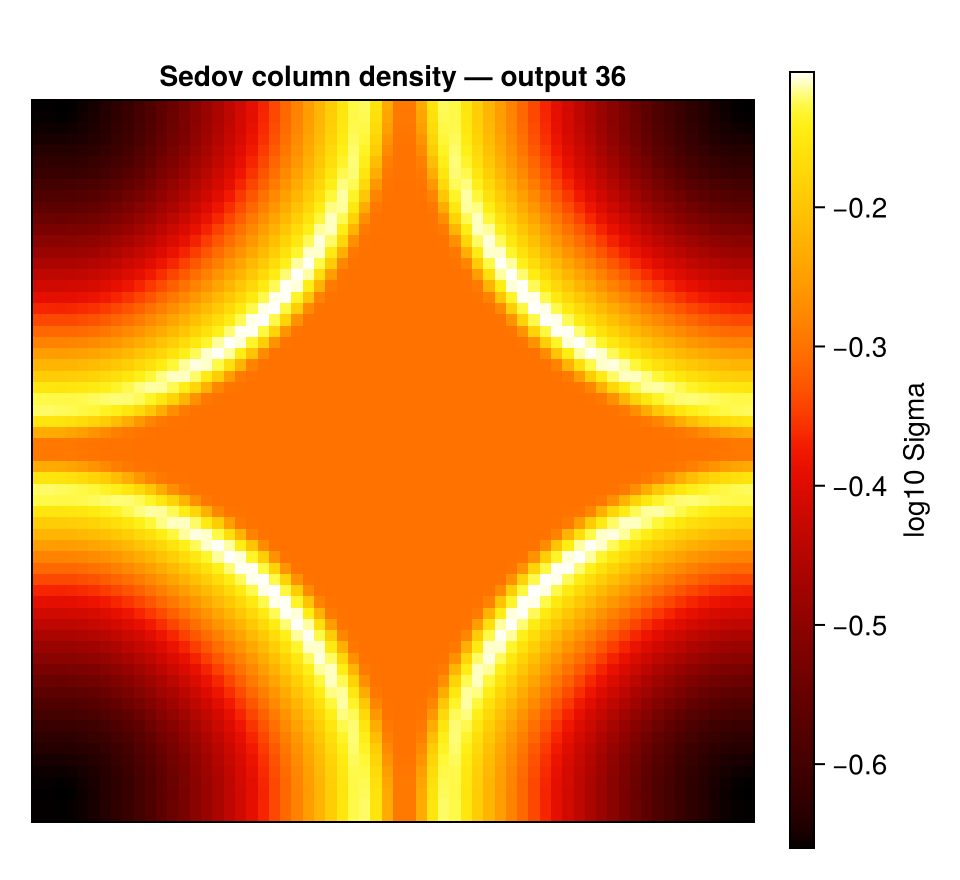

In [9]:
A = m.frames[end]
fig = Figure(size = (480, 440))
ax  = Axis(fig[1,1]; aspect = DataAspect(),
           title = "Sedov column density — output $(m.outputs[end])")
hidedecorations!(ax)
hm = heatmap!(ax, log10.(max.(A, 1e-30)); colormap = :fire)
Colorbar(fig[1,2], hm; label = "log10 Sigma")
fig

## See also

- [`timeseries`](@ref), the same outputs/loading machinery, reducing each snapshot to a row instead of a frame.
- [`projection`](@ref), the per-frame projection engine and its view keywords.
- [Auto-Frame](galaxyframe.md), `face_on`/`edge_on` for an oriented movie.